In [1]:
import pandas as pd
coding = pd.read_csv('../data/meta_data/ukb_phenotype_info/data_coding/coding_000019.tsv', sep='\t')
coding

,coding,meaning,node_id,parent_id,selectable
0,A00,A00 Cholera,2860,230,Y
1,A000,"A00.0 Cholera due to Vibrio cholerae 01, biova...",2870,2860,Y
2,A001,"A00.1 Cholera due to Vibrio cholerae 01, biova...",2880,2860,Y
3,A009,"A00.9 Cholera, unspecified",2890,2860,Y
4,A01,A01 Typhoid and paratyphoid fevers,2900,230,Y
...,...,...,...,...,...
19185,Z992,Z99.2 Dependence on renal dialysis,191500,191470,Y
19186,Z993,Z99.3 Dependence on wheelchair,191510,191470,Y
19187,Z994,Z99.4 Dependence on artificial heart,191520,191470,Y
19188,Z998,Z99.8 Dependence on other enabling machines an...,191530,191470,Y


In [3]:
pdata = coding[coding['coding'].map(lambda x: len(x)==3)]

In [4]:
pdata

,coding,meaning,node_id,parent_id,selectable
0,A00,A00 Cholera,2860,230,Y
4,A01,A01 Typhoid and paratyphoid fevers,2900,230,Y
10,A02,A02 Other Salmonella infections,2960,230,Y
16,A03,A03 Shigellosis,3020,230,Y
23,A04,A04 Other bacterial intestinal infections,3090,230,Y
...,...,...,...,...,...
19149,Z95,Z95 Presence of cardiac and vascular implants ...,191140,2830,Y
19158,Z96,Z96 Presence of other functional implants,191230,2830,Y
19169,Z97,Z97 Presence of other devices,191340,2830,Y
19177,Z98,Z98 Other postsurgical states,191420,2830,Y


In [12]:
pdata[pdata['meaning'].map(lambda x: 'stroke' in x.lower() or 'mobility' in x.lower())]['meaning'].tolist()

['I64 Stroke, not specified as haemorrhage or infarction',
 'R26 Abnormalities of gait and mobility']

In [11]:
import ollama
# Example: List installed models
print(ollama.list())

models=[Model(model='qwen3-coder:30b', modified_at=datetime.datetime(2025, 10, 16, 11, 58, 53, 694440, tzinfo=TzInfo(-04:00)), digest='06c1097efce0431c2045fe7b2e5108366e43bee1b4603a7aded8f21689e90bca', size=18556700761, details=ModelDetails(parent_model='', format='gguf', family='qwen3moe', families=['qwen3moe'], parameter_size='30.5B', quantization_level='Q4_K_M')), Model(model='qwen3-embedding:latest', modified_at=datetime.datetime(2025, 9, 24, 17, 28, 28, 486124, tzinfo=TzInfo(-04:00)), digest='64b933495768fbd3b87c20583d379728a07471e0c66733a9df87cd1901b3c44b', size=4676805193, details=ModelDetails(parent_model='', format='gguf', family='qwen3', families=['qwen3'], parameter_size='7.6B', quantization_level='Q4_K_M'))]


In [32]:
from tqdm import tqdm
responses = []
for prompt in tqdm(pdata['meaning'].tolist()):
    responses.append(ollama.embed(
        model='qwen3-embedding:latest',
        input=prompt
    ).embeddings)


  0%|                                                  | 0/2066 [00:00<?, ?it/s]

ERROR! Session/line number was not unique in database. History logging moved to new session 667


100%|███████████████████████████████████████| 2066/2066 [15:06<00:00,  2.28it/s]


In [ ]:

import torch

In [36]:
embeddings = torch.FloatTensor(responses).squeeze()

In [46]:

corr = torch.corrcoef(embeddings)

In [49]:
corr.shape

torch.Size([2066, 2066])

In [48]:
distance = ((embeddings[:, None] - embeddings[None])**2).sum(-1)
distance.shape

torch.Size([2066, 2066])

In [43]:
pdata['meaning'].tolist()[240]

'C73 Malignant neoplasm of thyroid gland'

In [53]:
distance = (distance - distance.min()) / (distance.max() - distance.min())

['A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A']

In [63]:
icd2ch_str = '''
Chapter I Certain infectious and parasitic diseases-
A00-A09 Intestinal infectious diseases32122
A15-A19 Tuberculosis463
A20-A28 Certain zoonotic bacterial diseases85
A30-A49 Other bacterial diseases24828
A50-A64 Infections with a predominantly sexual mode of transmission358
A65-A69 Other spirochaetal diseases158
A70-A74 Other diseases caused by chlamydiae14
A75-A79 Rickettsioses16
A80-A89 Viral infections of the central nervous system510
A92-A99 Arthropod-borne viral fevers and viral haemorrhagic fevers6
B00-B09 Viral infections characterized by skin and mucous membrane lesions4187
B15-B19 Viral hepatitis1659
B20-B24 Human immunodeficiency virus [HIV] disease310
B25-B34 Other viral diseases4374
B35-B49 Mycoses10524
B50-B64 Protozoal diseases523
B65-B83 Helminthiases302
B85-B89 Pediculosis, acariasis and other infestations118
B90-B94 Sequelae of infectious and parasitic diseases521
B95-B98 Bacterial, viral and other infectious agents45541
B99-B99 Other infectious diseases956
Chapter II Neoplasms-
C00-C14 Malignant neoplasms of lip, oral cavity and pharynx2854
C15-C26 Malignant neoplasms of digestive organs26369
C30-C39 Malignant neoplasms of respiratory and intrathoracic organs10486
C40-C41 Malignant neoplasms of bone and articular cartilage315
C43-C44 Melanoma and other malignant neoplasms of skin41388
C45-C49 Malignant neoplasms of mesothelial and soft tissue2273
C50-C50 Malignant neoplasm of breast23908
C51-C58 Malignant neoplasms of female genital organs6387
C60-C63 Malignant neoplasms of male genital organs16702
C64-C68 Malignant neoplasms of urinary tract10122
C69-C72 Malignant neoplasms of eye, brain and other parts of central nervous system2364
C73-C75 Malignant neoplasms of thyroid and other endocrine glands1006
C76-C80 Malignant neoplasms of ill-defined, secondary and unspecified sites60880
C81-C96 Malignant neoplasms, stated or presumed to be primary, of lymphoid, haematopoietic and related tissue13786
C97-C97 Malignant neoplasms of independent (primary) multiple sites2011
D00-D09 In situ neoplasms11665
D10-D36 Benign neoplasms124444
D37-D48 Neoplasms of uncertain or unknown behaviour13071
Chapter III Diseases of the blood and blood-forming organs and certain disorders involving the immune mechanism-
D50-D53 Nutritional anaemias33143
D55-D59 Haemolytic anaemias2147
D60-D64 Aplastic and other anaemias37584
D65-D69 Coagulation defects, purpura and other haemorrhagic conditions9331
D70-D77 Other diseases of blood and blood-forming organs12770
D80-D89 Certain disorders involving the immune mechanism3593
Chapter IV Endocrine, nutritional and metabolic diseases-
E00-E07 Disorders of thyroid gland44663
E10-E14 Diabetes mellitus69720
E15-E16 Other disorders of glucose regulation and pancreatic internal secretion4344
E20-E35 Disorders of other endocrine glands9734
E40-E46 Malnutrition753
E50-E64 Other nutritional deficiencies13791
E65-E68 Obesity and other hyperalimentation45891
E70-E90 Metabolic disorders173831
Chapter V Mental and behavioural disorders-
F00-F09 Organic, including symptomatic, mental disorders26178
F10-F19 Mental and behavioural disorders due to psychoactive substance use46052
F20-F29 Schizophrenia, schizotypal and delusional disorders3673
F30-F39 Mood [affective] disorders41336
F40-F48 Neurotic, stress-related and somatoform disorders36945
F50-F59 Behavioural syndromes associated with physiological disturbances and physical factors1488
F60-F69 Disorders of adult personality and behaviour1182
F70-F79 Mental retardation275
F80-F89 Disorders of psychological development1094
F90-F98 Behavioural and emotional disorders with onset usually occurring in childhood and adolescence182
F99-F99 Unspecified mental disorder409
Chapter VI Diseases of the nervous system-
G00-G09 Inflammatory diseases of the central nervous system1738
G10-G14 Systemic atrophies primarily affecting the central nervous system1304
G20-G26 Extrapyramidal and movement disorders9213
G30-G32 Other degenerative diseases of the nervous system8964
G35-G37 Demyelinating diseases of the central nervous system2757
G40-G47 Episodic and paroxysmal disorders41063
G50-G59 Nerve, nerve root and plexus disorders39734
G60-G64 Polyneuropathies and other disorders of the peripheral nervous system8162
G70-G73 Diseases of myoneural junction and muscle1457
G80-G83 Cerebral palsy and other paralytic syndromes7622
G90-G99 Other disorders of the nervous system13970
Chapter VII Diseases of the eye and adnexa-
H00-H06 Disorders of eyelid, lacrimal system and orbit26370
H10-H13 Disorders of conjunctiva3049
H15-H22 Disorders of sclera, cornea, iris and ciliary body10343
H25-H28 Disorders of lens102533
H30-H36 Disorders of choroid and retina33032
H40-H42 Glaucoma21907
H43-H45 Disorders of vitreous body and globe6343
H46-H48 Disorders of optic nerve and visual pathways1479
H49-H52 Disorders of ocular muscles, binocular movement, accommodation and refraction19884
H53-H54 Visual disturbances and blindness14147
H55-H59 Other disorders of eye and adnexa3511
Chapter VIII Diseases of the ear and mastoid process-
H60-H62 Diseases of external ear3288
H65-H75 Diseases of middle ear and mastoid7677
H80-H83 Diseases of inner ear6185
H90-H95 Other disorders of ear23076
Chapter IX Diseases of the circulatory system-
I00-I02 Acute rheumatic fever75
I05-I09 Chronic rheumatic heart diseases14442
I10-I15 Hypertensive diseases169852
I20-I25 Ischaemic heart diseases173720
I26-I28 Pulmonary heart disease and diseases of pulmonary circulation14792
I30-I52 Other forms of heart disease201019
I60-I69 Cerebrovascular diseases43101
I70-I79 Diseases of arteries, arterioles and capillaries32762
I80-I89 Diseases of veins, lymphatic vessels and lymph nodes, not elsewhere classified77144
I95-I99 Other and unspecified disorders of the circulatory system26080
Chapter X Diseases of the respiratory system-
J00-J06 Acute upper respiratory infections6419
J09-J18 Influenza and pneumonia46314
J20-J22 Other acute lower respiratory infections20575
J30-J39 Other diseases of upper respiratory tract40240
J40-J47 Chronic lower respiratory diseases103772
J60-J70 Lung diseases due to external agents5591
J80-J84 Other respiratory diseases principally affecting the interstitium7410
J85-J86 Suppurative and necrotic conditions of lower respiratory tract1119
J90-J94 Other diseases of pleura27058
J95-J99 Other diseases of the respiratory system30938
Chapter XI Diseases of the digestive system-
K00-K14 Diseases of oral cavity, salivary glands and jaws38508
K20-K31 Diseases of oesophagus, stomach and duodenum254835
K35-K38 Diseases of appendix6812
K40-K46 Hernia107039
K50-K52 Noninfective enteritis and colitis41224
K55-K64 Other diseases of intestines287541
K65-K67 Diseases of peritoneum12376
K70-K77 Diseases of liver27238
K80-K87 Disorders of gallbladder, biliary tract and pancreas67373
K90-K93 Other diseases of the digestive system36615
Chapter XII Diseases of the skin and subcutaneous tissue-
L00-L08 Infections of the skin and subcutaneous tissue28299
L10-L14 Bullous disorders582
L20-L30 Dermatitis and eczema12156
L40-L45 Papulosquamous disorders8827
L50-L54 Urticaria and erythema3020
L55-L59 Radiation-related disorders of the skin and subcutaneous tissue7725
L60-L75 Disorders of skin appendages18178
L80-L99 Other disorders of the skin and subcutaneous tissue47367
Chapter XIII Diseases of the musculoskeletal system and connective tissue-
M00-M03 Infectious arthropathies1274
M05-M14 Inflammatory polyarthropathies80611
M15-M19 Arthrosis160920
M20-M25 Other joint disorders99996
M30-M36 Systemic connective tissue disorders11237
M40-M43 Deforming dorsopathies12316
M45-M49 Spondylopathies54718
M50-M54 Other dorsopathies79889
M60-M63 Disorders of muscles3477
M65-M68 Disorders of synovium and tendon18630
M70-M79 Other soft tissue disorders84367
M80-M85 Disorders of bone density and structure42179
M86-M90 Other osteopathies8458
M91-M94 Chondropathies2556
M95-M99 Other disorders of the musculoskeletal system and connective tissue2504
Chapter XIV Diseases of the genitourinary system-
N00-N08 Glomerular diseases5176
N10-N16 Renal tubulo-interstitial diseases14492
N17-N19 Renal failure67111
N20-N23 Urolithiasis17024
N25-N29 Other disorders of kidney and ureter10711
N30-N39 Other diseases of urinary system86904
N40-N51 Diseases of male genital organs55641
N60-N64 Disorders of breast9917
N70-N77 Inflammatory diseases of female pelvic organs10640
N80-N98 Noninflammatory disorders of female genital tract131802
N99-N99 Other disorders of the genitourinary system2063
Chapter XV Pregnancy, childbirth and the puerperium-
O00-O08 Pregnancy with abortive outcome5651
O10-O16 Oedema, proteinuria and hypertensive disorders in pregnancy, childbirth and the puerperium2140
O20-O29 Other maternal disorders predominantly related to pregnancy4963
O30-O48 Maternal care related to the fetus and amniotic cavity and possible delivery problems13390
O60-O75 Complications of labour and delivery21421
O80-O84 Delivery3681
O85-O92 Complications predominantly related to the puerperium883
O94-O99 Other obstetric conditions, not elsewhere classified2637
Chapter XVI Certain conditions originating in the perinatal period-
P00-P04 Fetus and newborn affected by maternal factors and by complications of pregnancy, labour and delivery3
P05-P08 Disorders related to length of gestation and fetal growth5
P10-P15 Birth trauma23
P20-P29 Respiratory and cardiovascular disorders specific to the perinatal period7
P35-P39 Infections specific to the perinatal period6
P50-P61 Haemorrhagic and haematological disorders of fetus and newborn1
P80-P83 Conditions involving the integument and temperature regulation of fetus and newborn4
P90-P96 Other disorders originating in the perinatal period3
Chapter XVII Congenital malformations, deformations and chromosomal abnormalities-
Q00-Q07 Congenital malformations of the nervous system641
Q10-Q18 Congenital malformations of eye, ear, face and neck761
Q20-Q28 Congenital malformations of the circulatory system3331
Q30-Q34 Congenital malformations of the respiratory system172
Q35-Q37 Cleft lip and cleft palate63
Q38-Q45 Other congenital malformations of the digestive system1842
Q50-Q56 Congenital malformations of genital organs1220
Q60-Q64 Congenital malformations of the urinary system2192
Q65-Q79 Congenital malformations and deformations of the musculoskeletal system1925
Q80-Q89 Other congenital malformations1296
Q90-Q99 Chromosomal abnormalities, not elsewhere classified264
Chapter XVIII Symptoms, signs and abnormal clinical and laboratory findings, not elsewhere classified-
R00-R09 Symptoms and signs involving the circulatory and respiratory systems156207
R10-R19 Symptoms and signs involving the digestive system and abdomen180403
R20-R23 Symptoms and signs involving the skin and subcutaneous tissue18475
R25-R29 Symptoms and signs involving the nervous and musculoskeletal systems43232
R30-R39 Symptoms and signs involving the urinary system77771
R40-R46 Symptoms and signs involving cognition, perception, emotional state and behaviour39963
R47-R49 Symptoms and signs involving speech and voice8326
R50-R69 General symptoms and signs155019
R70-R79 Abnormal findings on examination of blood, without diagnosis28397
R80-R82 Abnormal findings on examination of urine, without diagnosis1885
R83-R89 Abnormal findings on examination of other body fluids, substances and tissues, without diagnosis3300
R90-R94 Abnormal findings on diagnostic imaging and in function studies, without diagnosis33418
R95-R99 Ill-defined and unknown causes of mortality11
Chapter XIX Injury, poisoning and certain other consequences of external causes-
S00-S09 Injuries to the head36393
S10-S19 Injuries to the neck2462
S20-S29 Injuries to the thorax10869
S30-S39 Injuries to the abdomen, lower back, lumbar spine and pelvis10031
S40-S49 Injuries to the shoulder and upper arm10327
S50-S59 Injuries to the elbow and forearm17269
S60-S69 Injuries to the wrist and hand19427
S70-S79 Injuries to the hip and thigh11148
S80-S89 Injuries to the knee and lower leg19164
S90-S99 Injuries to the ankle and foot4655
T00-T07 Injuries involving multiple body regions1141
T08-T14 Injuries to unspecified part of trunk, limb or body region1110
T15-T19 Effects of foreign body entering through natural orifice2159
T20-T25 Burns and corrosions of external body surface, specified by site1451
T26-T28 Burns and corrosions confined to eye and internal organs71
T29-T32 Burns and corrosions of multiple and unspecified body regions735
T33-T35 Frostbite11
T36-T50 Poisoning by drugs, medicaments and biological substances11805
T51-T65 Toxic effects of substances chiefly nonmedicinal as to source2267
T66-T78 Other and unspecified effects of external causes2953
T79-T79 Certain early complications of trauma1176
T80-T88 Complications of surgical and medical care, not elsewhere classified66450
T90-T98 Sequelae of injuries, of poisoning and of other consequences of external causes5005
Chapter XX External causes of morbidity and mortality-
V01-V09 Pedestrian injured in transport accident1270
V10-V19 Pedal cyclist injured in transport accident3961
V20-V29 Motorcycle rider injured in transport accident1366
V30-V39 Occupant of three-wheeled motor vehicle injured in transport accident22
V40-V49 Car occupant injured in transport accident2448
V50-V59 Occupant of pick-up truck or van injured in transport accident84
V60-V69 Occupant of heavy transport vehicle injured in transport accident87
V70-V79 Bus occupant injured in transport accident357
V80-V89 Other land transport accidents974
V90-V94 Water transport accidents158
V95-V97 Air and space transport accidents90
V98-V99 Other and unspecified transport accidents47
W00-W19 Falls61521
W20-W49 Exposure to inanimate mechanical forces11180
W50-W64 Exposure to animate mechanical forces3733
W65-W74 Accidental drowning and submersion38
W75-W84 Other accidental threats to breathing1108
W85-W99 Exposure to electric current, radiation and extreme ambient air temperature and pressure159
X00-X09 Exposure to smoke, fire and flames260
X10-X19 Contact with heat and hot substances519
X20-X29 Contact with venomous animals and plants330
X30-X39 Exposure to forces of nature178
X40-X49 Accidental poisoning by and exposure to noxious substances2993
X50-X57 Overexertion, travel and privation2435
X58-X59 Accidental exposure to other and unspecified factors8080
X60-X84 Intentional self-harm9068
X85-X99 Assault297
Y00-Y09 Assault1583
Y10-Y34 Event of undetermined intent251
Y35-Y36 Legal intervention and operations of war5
Y40-Y59 Drugs, medicaments and biological substances causing adverse effects in therapeutic use23657
Y60-Y69 Misadventures to patients during surgical and medical care2801
Y70-Y82 Medical devices associated with adverse incidents in diagnostic and therapeutic use890
Y83-Y84 Surgical and other medical procedures as the cause of abnormal reaction of the patient, or of later complication, without mention of misadventure at the time of the procedure51338
Y85-Y89 Sequelae of external causes of morbidity and mortality3062
Y90-Y98 Supplementary factors related to causes of morbidity and mortality classified elsewhere8415
Chapter XXI Factors influencing health status and contact with health services-
Z00-Z13 Persons encountering health services for examination and investigation139593
Z20-Z29 Persons with potential health hazards related to communicable diseases9347
Z30-Z39 Persons encountering health services in circumstances related to reproduction33426
Z40-Z54 Persons encountering health services for specific procedures and health care218061
Z55-Z65 Persons with potential health hazards related to socioeconomic and psychosocial circumstances12867
Z70-Z76 Persons encountering health services in other circumstances49039
Z80-Z99 Persons with potential health hazards related to family and personal history and certain conditions influencing health status870585
Chapter XXII Codes for special purposes-
U00-U49 Provisional assignment of new diseases of uncertain etiology or emergency use19180
U82-U85 Resistance to antimicrobial and antineoplastic drugs
'''

In [69]:
import roman
integer_value = roman.fromRoman('XXII')
integer_value

22

In [77]:
type(integer_value)

int

In [72]:
icd2ch = {}
for line in icd2ch_str.split('\n')[1:-1]:
    if line.startswith('Ch'):
        cur_v = roman.fromRoman(line.split(' ')[1])
    else:
        startend = line.split(' ')[0]
        s, e = startend.split('-')
        assert s[0] == e[0], f'{s}, {e}'
        for i in range(int(s[1:]), int(e[1:])+1):
            icd2ch[f'{s[0]}{i:02d}'] = cur_v
len(icd2ch)

2205

In [110]:
icd = [icd2ch[x[:3]] if x[:3] in icd2ch else None for x in pdata['meaning'].tolist() ]
icd[:10]

[1, 1, 1, 1, 1, 1, 1, 1, 1, 1]

In [111]:

ticks = [icd[0]]
tick_loc = [0]
for loc, i in enumerate(icd[1:]):
    if i not in ticks and i is not None:
        ticks.append(i)
        tick_loc.append(loc+1)

len(ticks)

22

In [112]:
p_tick_loc = tick_loc + [len(icd)]
tick_loc = []
for i, loc in enumerate(p_tick_loc[:-1]):
    tick_loc.append((p_tick_loc[i+1]+loc)/2)

In [113]:
org_icd = [x[:1] for x in pdata['meaning'].tolist() ]

org_ticks = [org_icd[0]]
org_tick_loc = [0]
for loc, i in enumerate(org_icd[1:]):
    if i not in org_ticks and i is not None:
        org_ticks.append(i)
        org_tick_loc.append(loc+1)

len(ticks)
org_p_tick_loc = org_tick_loc + [len(icd)]
org_tick_loc = []
for i, loc in enumerate(org_p_tick_loc[:-1]):
    org_tick_loc.append((org_p_tick_loc[i+1]+loc)/2)


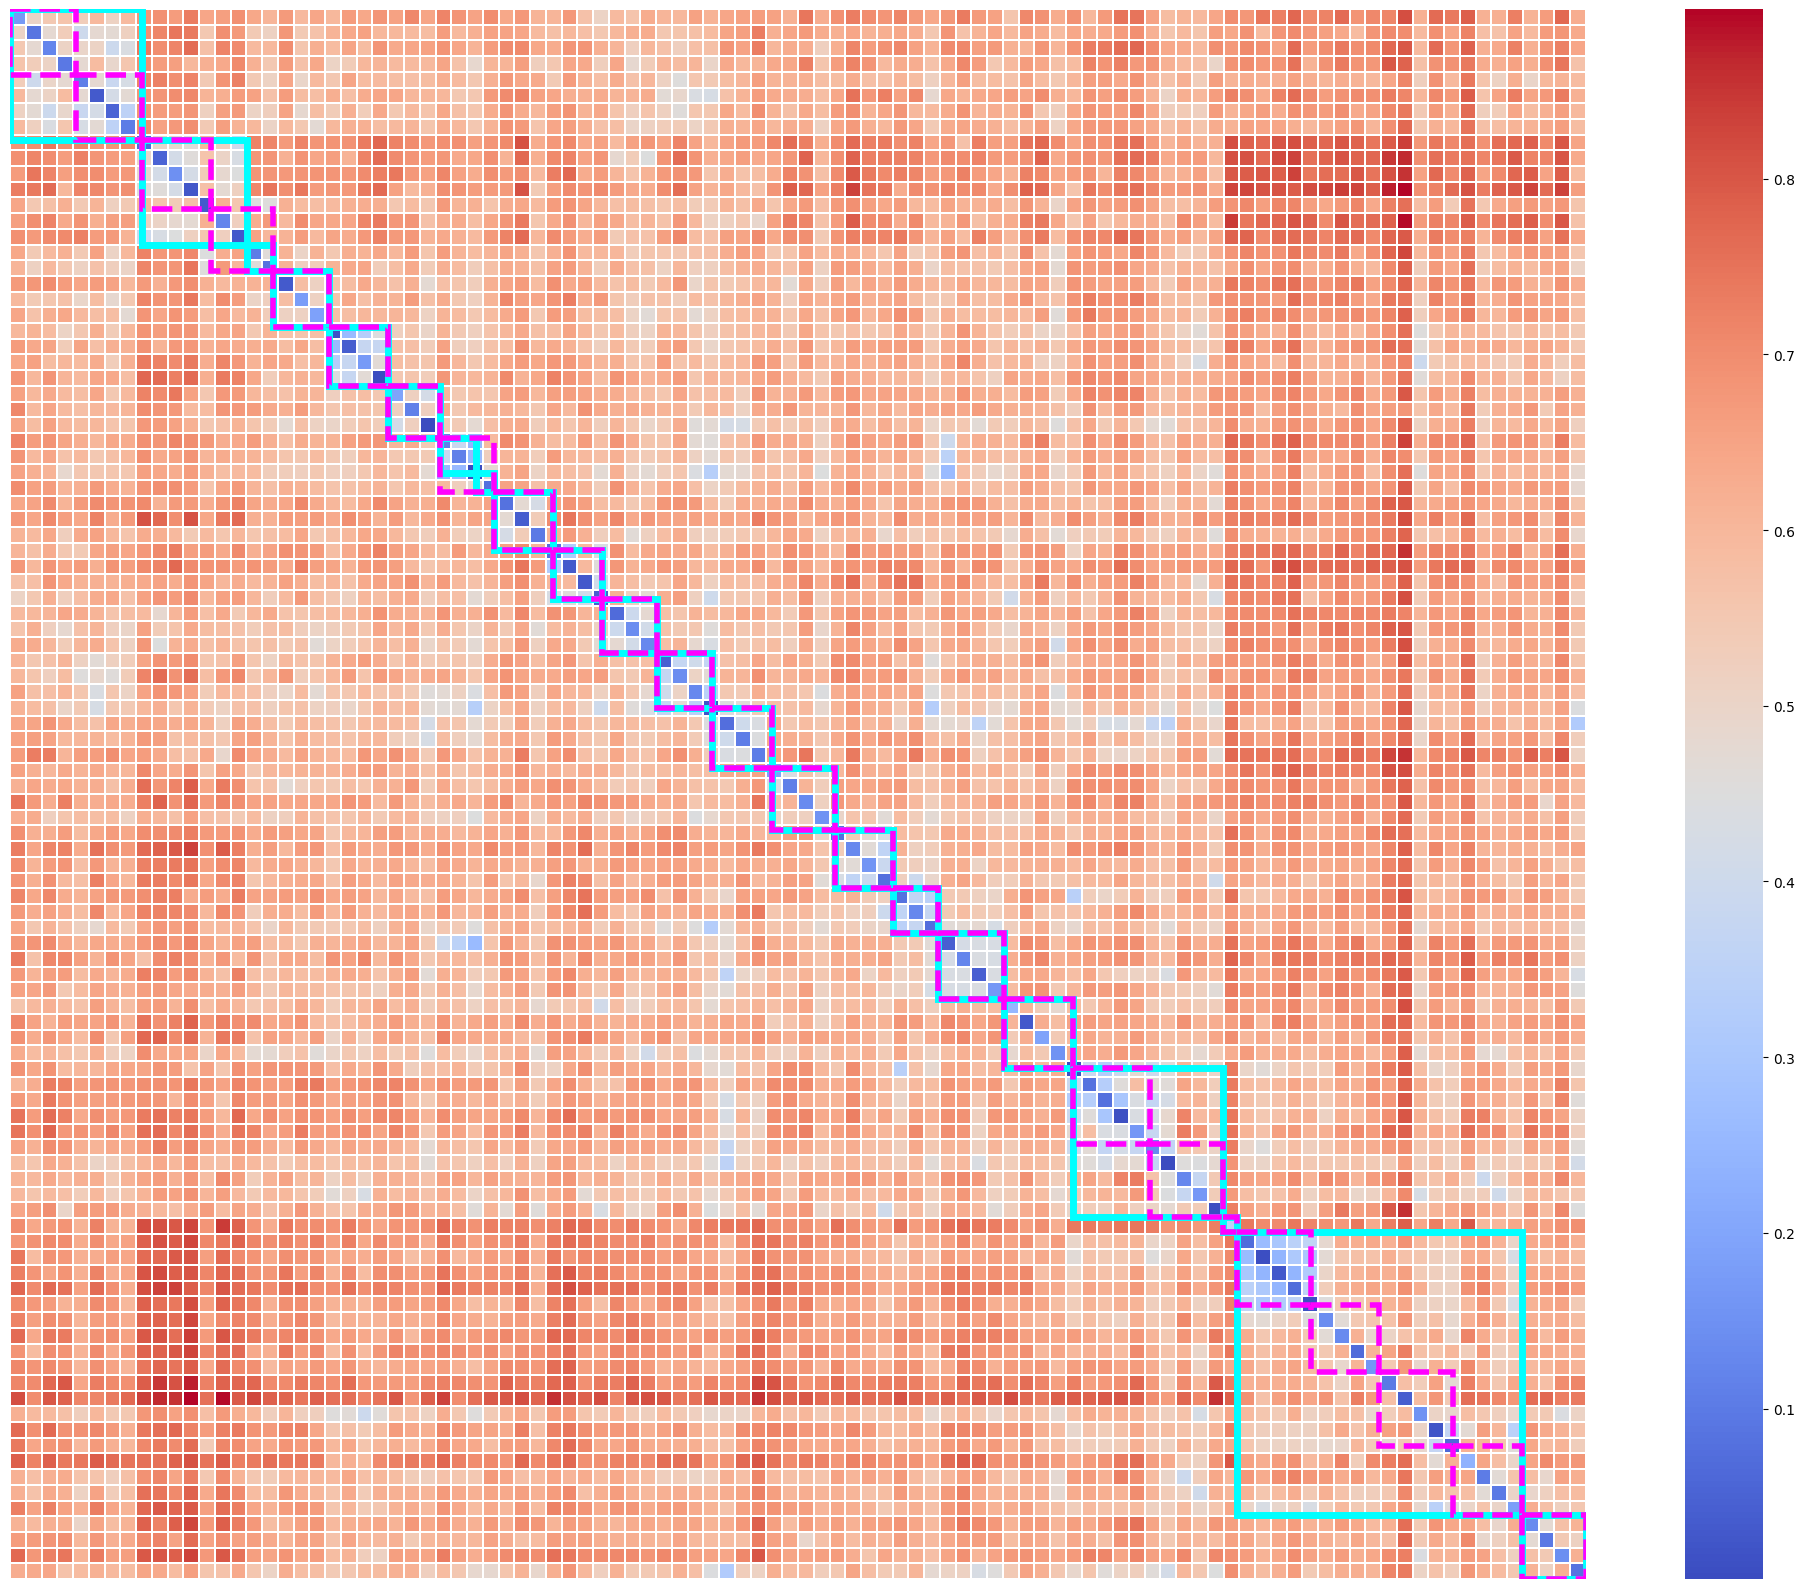

In [173]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns
import numpy as np
import torch.nn.functional as F

downr = distance.shape[0] / 100
plt.figure(figsize=(20, 16))
# 1. Generate data
data = F.interpolate(distance[None, None], size=(100, 100), mode='bilinear', align_corners=False).squeeze()

# 2. Create the heatmap directly
ax = sns.heatmap(data, linewidths=0.01, linecolor='white', cmap='coolwarm')
offset = 0
 
for i, loc in enumerate(p_tick_loc[:-1]):
    # 4. Define the bounding box coordinates (example: bottom-left corner at x=2, y=3 with width=4, height=4)
    # Coordinates are in data units (which correspond to the array indices here)
    x_min, y_min = loc , loc 
    box_width, box_height = p_tick_loc[i+1]-loc, p_tick_loc[i+1]-loc
    
    # 5. Create a Rectangle patch
    # The Rectangle takes the bottom-left corner (x, y), width, and height
    bbox = patches.Rectangle((x_min / downr, y_min / downr), box_width / downr, box_height / downr,
                             linewidth=5, edgecolor='cyan', facecolor='none', alpha=1)
    
    # 6. Add the bounding box to the Axes
    ax.add_patch(bbox)

# 3. Display the heatmap using imshow
# 'cmap="hot"' gives the classic red/yellow heatmap colors
# 'origin="lower"' ensures the (0,0) index is at the bottom-left corner
# ax.imshow(distance.numpy(), cmap='seismic', origin='lower')
 
for i, loc in enumerate(org_p_tick_loc[:-1]):
    # 4. Define the bounding box coordinates (example: bottom-left corner at x=2, y=3 with width=4, height=4)
    # Coordinates are in data units (which correspond to the array indices here)
    x_min, y_min = loc + offset, loc + offset
    box_width, box_height = org_p_tick_loc[i+1]-loc - 2*offset, org_p_tick_loc[i+1]-loc - 2*offset
    
    # 5. Create a Rectangle patch
    # The Rectangle takes the bottom-left corner (x, y), width, and height
    bbox = patches.Rectangle((x_min / downr, y_min / downr), box_width / downr, box_height / downr,
                             linewidth=4, edgecolor='magenta', facecolor='none', alpha=1, linestyle='--')
    
    # 6. Add the bounding box to the Axes
    ax.add_patch(bbox)

# plt.xticks(ticks, [x*3 for x in tick_loc])
# ax.set_yticks(ticks, tick_loc)
plt.axis('off')
plt.tight_layout()
# 5. Display the plot
# plt.title('Heatmap with Bounding Box (No Saving)')
# plt.show()


In [175]:
full_icd = [x[:3] for x in pdata['meaning'].tolist() ]
full_icd[:10]

['A00', 'A01', 'A02', 'A03', 'A04', 'A05', 'A06', 'A07', 'A08', 'A09']

In [178]:
from tqdm import trange
icdpair2dist = {}
for i in trange(len(distance)):
    for j in range(len(distance)):
        icdpair2dist[f'{full_icd[i]}-{full_icd[j]}'] = distance[i, j].item()
len(icdpair2dist)

4268356

In [179]:
torch.save({'distance': distance, 'ticks': full_icd}, 'icd2icd_meaning_distance.pth')

<Axes: >

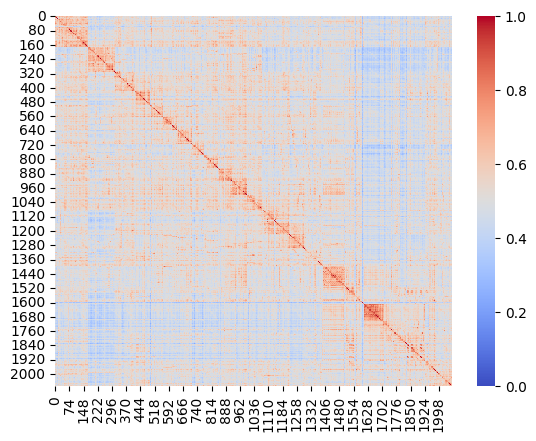

In [52]:
sns.heatmap(corr.numpy(), cmap='coolwarm', vmin=0, vmax=1)
